In [1]:
# ============================================
# ENVIRONMENT SETUP 
# Run this at the start of every session/notebook
# ============================================

import os
import sys

# Configuration
WORKSPACE_PACKAGES = '/workspace/python_packages'

# Add to Python path (prepend to ensure priority)
if WORKSPACE_PACKAGES not in sys.path:
    sys.path.insert(0, WORKSPACE_PACKAGES)

# Configure all cache directories to use persistent workspace
cache_config = {
    'HF_HOME': '/workspace/.cache/huggingface',
    'TRANSFORMERS_CACHE': '/workspace/.cache/huggingface/transformers',
    'HF_DATASETS_CACHE': '/workspace/.cache/huggingface/datasets',
    'TORCH_HOME': '/workspace/.cache/torch',
    'PIP_CACHE_DIR': '/workspace/.cache/pip',
    'TMPDIR': '/workspace/tmp',
    'MPLCONFIGDIR': '/workspace/.cache/matplotlib'
}

# Set environment variables
for key, path in cache_config.items():
    os.environ[key] = path
    os.makedirs(path, exist_ok=True)

# CUDA library path
cuda_path = '/usr/local/cuda/lib64'
if os.path.exists(cuda_path):
    os.environ['LD_LIBRARY_PATH'] = f"{cuda_path}:{os.environ.get('LD_LIBRARY_PATH', '')}"

print("✓ Environment configured")
print(f"✓ Python path: {WORKSPACE_PACKAGES}")
print(f"✓ All caches point to /workspace")

# Import libraries
print("\nImporting libraries...")

from typing import Optional, Tuple, List, Dict, Any
import numpy as np
import torch
from transformers import AutoModel, AutoModelForSequenceClassification, AutoTokenizer
from datasets import load_dataset
from ripser import ripser
from persim import plot_diagrams, bottleneck
import matplotlib.pyplot as plt
import seaborn as sns
import textwrap
import json
import pickle
from pathlib import Path
from datetime import datetime
import hashlib

print("✓ All libraries imported successfully")
print(f"\nPyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")
    print(f"CUDA version: {torch.version.cuda}")

print("\n🚀 Ready to go!")

✓ Environment configured
✓ Python path: /workspace/python_packages
✓ All caches point to /workspace

Importing libraries...


/workspace/python_packages/transformers/utils/hub.py:127: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


✓ All libraries imported successfully

PyTorch version: 2.3.1+cu118
CUDA available: True
CUDA device: NVIDIA RTX A6000
CUDA version: 11.8

🚀 Ready to go!


In [2]:
"""
Aggregated TDA Visualization Suite
Pool-level analysis across 20+ samples per model
Inspired by: Persistence Images, Persistence Landscapes, Betti Curves from TDA literature
"""

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pickle
from scipy.stats import gaussian_kde
from scipy.ndimage import gaussian_filter
import pandas as pd
from typing import List, Dict, Tuple
import warnings
warnings.filterwarnings('ignore')


# ==============================================================================
# DATA LOADING
# ==============================================================================

def load_multi_experiment_data(exp_dirs: Dict[str, Path], use_h2_experimental: bool = False):
    """
    Load data from multiple experiments
    
    Args:
        exp_dirs: Dict like {"BERT": Path(...), "RoBERTa": Path(...)}
        use_h2_experimental: If True, load from h2_experimental folder (has H0, H1, H2)
                            If False, load from main folder (may only have H0, H1)
        
    Returns:
        Nested dict: {model: {condition: {res_list, texts, attn_maps, Ds}}}
    """
    all_data = {}
    
    for model_name, exp_dir in exp_dirs.items():
        print(f"Loading {model_name}...")
        
        model_data = {}
        for condition in ["sandbagging", "non_sandbagging"]:
            condition_dir = exp_dir / condition
            
            # Determine which persistence diagrams to load
            if use_h2_experimental:
                h2_dir = condition_dir / "h2_experimental"
                if not h2_dir.exists():
                    print(f"  ⚠ h2_experimental not found for {model_name}/{condition}, using main folder")
                    pkl_path = condition_dir / "persistence_diagrams.pkl"
                else:
                    pkl_path = h2_dir / "persistence_diagrams_h2.pkl"
            else:
                pkl_path = condition_dir / "persistence_diagrams.pkl"
            
            # Load persistence diagrams
            if not pkl_path.exists():
                print(f"  ⚠ Persistence diagrams not found: {pkl_path}")
                continue
            
            with open(pkl_path, "rb") as f:
                res_list = pickle.load(f)
            
            # Load texts
            texts_path = condition_dir / "texts.txt"
            if texts_path.exists():
                with open(texts_path, "r", encoding="utf-8") as f:
                    texts = [line.strip() for line in f.readlines()]
            else:
                texts = [f"Sample {i}" for i in range(len(res_list))]
            
            # Load attention maps (optional)
            attn_path = condition_dir / "attention_maps.npy"
            if attn_path.exists():
                attn_maps = np.load(attn_path, allow_pickle=True)
                attn_maps = list(attn_maps)
            else:
                attn_maps = None
            
            # Load distance matrices (optional)
            dist_path = condition_dir / "distance_matrices.npy"
            if dist_path.exists():
                Ds = np.load(dist_path, allow_pickle=True)
                Ds = list(Ds)
            else:
                Ds = None
            
            model_data[condition] = {
                "res_list": res_list,
                "texts": texts,
                "attn_maps": attn_maps,
                "Ds": Ds
            }
            
            # Print info about what was loaded
            n_dims = len(res_list[0]['dgms']) if res_list else 0
            dims_str = f"H0"
            if n_dims > 1:
                dims_str += f", H1"
            if n_dims > 2:
                dims_str += f", H2"
            
            print(f"  ✓ {condition}: {len(res_list)} samples ({dims_str})")
            if attn_maps is not None:
                print(f"    - Attention maps: {len(attn_maps)}")
            if Ds is not None:
                print(f"    - Distance matrices: {len(Ds)}")
        
        all_data[model_name] = model_data
    
    return all_data

ModuleNotFoundError: No module named 'matplotlib'

In [3]:
# ==============================================================================
# VIZ 1: AGGREGATED KDE DIFFERENCE MAPS (POOL-LEVEL)
# ==============================================================================

def plot_aggregated_kde_difference(all_data: Dict, dim: int = 1, 
                                   figsize: Tuple = (18, 12), gridsize: int = 100):
    """
    Aggregate KDE difference maps across ALL samples for each model
    Shows overall distributional differences at the population level
    
    Based on: Topological persistence analysis (Edelsbrunner & Harer, 2008)
    """
    n_models = len(all_data)
    fig, axes = plt.subplots(n_models, 3, figsize=figsize)
    
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for model_idx, (model_name, model_data) in enumerate(all_data.items()):
        print(f"Processing {model_name}...")
        
        # Collect ALL points from ALL samples
        points_sb = []
        points_nsb = []
        
        for res in model_data['sandbagging']['res_list']:
            dgm = res['dgms'][dim]
            finite_dgm = dgm[np.isfinite(dgm).all(axis=1)]
            if len(finite_dgm) > 0:
                points_sb.append(finite_dgm)
        
        for res in model_data['non_sandbagging']['res_list']:
            dgm = res['dgms'][dim]
            finite_dgm = dgm[np.isfinite(dgm).all(axis=1)]
            if len(finite_dgm) > 0:
                points_nsb.append(finite_dgm)
        
        if not points_sb or not points_nsb:
            print(f"  ⚠ Skipping {model_name} - insufficient data")
            continue
        
        points_sb = np.vstack(points_sb)
        points_nsb = np.vstack(points_nsb)
        
        # Determine common limits
        all_points = np.vstack([points_sb, points_nsb])
        xlim = (all_points[:, 0].min(), all_points[:, 0].max())
        ylim = (all_points[:, 1].min(), all_points[:, 1].max())
        
        # Create grid
        x = np.linspace(xlim[0], xlim[1], gridsize)
        y = np.linspace(ylim[0], ylim[1], gridsize)
        X, Y = np.meshgrid(x, y)
        
        # Compute KDEs
        kde_sb = gaussian_kde(points_sb.T)
        kde_nsb = gaussian_kde(points_nsb.T)
        
        positions = np.vstack([X.ravel(), Y.ravel()])
        Z_sb = kde_sb(positions).reshape(X.shape)
        Z_nsb = kde_nsb(positions).reshape(X.shape)
        Z_diff = Z_sb - Z_nsb
        
        # Plot 1: Sandbagging KDE
        ax = axes[model_idx, 0]
        im = ax.contourf(X, Y, Z_sb, levels=20, cmap='Blues')
        ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], 'k--', alpha=0.3, linewidth=2)
        ax.set_xlabel('Birth', fontsize=11)
        ax.set_ylabel('Death', fontsize=11)
        ax.set_title(f'{model_name} - Sandbagging\nH{dim} (n={len(points_sb)} features)', 
                    fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Density')
        ax.set_aspect('equal', adjustable='box')
        
        # Plot 2: Non-sandbagging KDE
        ax = axes[model_idx, 1]
        im = ax.contourf(X, Y, Z_nsb, levels=20, cmap='Oranges')
        ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], 'k--', alpha=0.3, linewidth=2)
        ax.set_xlabel('Birth', fontsize=11)
        ax.set_ylabel('Death', fontsize=11)
        ax.set_title(f'{model_name} - Non-Sandbagging\nH{dim} (n={len(points_nsb)} features)', 
                    fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Density')
        ax.set_aspect('equal', adjustable='box')
        
        # Plot 3: Difference
        ax = axes[model_idx, 2]
        max_abs = np.abs(Z_diff).max()
        im = ax.contourf(X, Y, Z_diff, levels=20, cmap='RdBu_r', 
                        vmin=-max_abs, vmax=max_abs)
        ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], 'k--', alpha=0.3, linewidth=2)
        ax.set_xlabel('Birth', fontsize=11)
        ax.set_ylabel('Death', fontsize=11)
        ax.set_title(f'{model_name} - Difference\nH{dim} (SB - NSB)', 
                    fontsize=11, fontweight='bold')
        plt.colorbar(im, ax=ax, label='Density Difference')
        ax.set_aspect('equal', adjustable='box')
    
    plt.suptitle(f'Aggregated KDE Difference Maps - H{dim}\n(All samples pooled)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ==============================================================================
# VIZ 2: PERSISTENCE IMAGES (Adams et al., 2017)
# ==============================================================================

def compute_persistence_image(dgms: List[np.ndarray], xlim: Tuple, ylim: Tuple,
                              resolution: int = 50, sigma: float = 0.01):
    """
    Compute persistence image from persistence diagrams
    
    Reference: Adams et al. (2017) "Persistence Images: A Stable Vector 
    Representation of Persistent Homology"
    
    Persistence images provide a stable vectorization of persistence diagrams
    """
    # Create grid
    x = np.linspace(xlim[0], xlim[1], resolution)
    y = np.linspace(ylim[0], ylim[1], resolution)
    X, Y = np.meshgrid(x, y)
    
    # Initialize image
    img = np.zeros((resolution, resolution))
    
    # Weight function: persistence (death - birth)
    for dgm in dgms:
        finite_dgm = dgm[np.isfinite(dgm).all(axis=1)]
        if len(finite_dgm) == 0:
            continue
        
        births = finite_dgm[:, 0]
        deaths = finite_dgm[:, 1]
        persistence = deaths - births
        
        # Add weighted Gaussians for each point
        for b, d, p in zip(births, deaths, persistence):
            # Weight by persistence
            gaussian = p * np.exp(-((X - b)**2 + (Y - d)**2) / (2 * sigma**2))
            img += gaussian
    
    return img, X, Y


def plot_persistence_images(all_data: Dict, dim: int = 1, 
                           figsize: Tuple = (18, 12), resolution: int = 50):
    """
    Plot persistence images for all models and conditions
    
    Persistence images are stable, vectorized representations that:
    - Weight features by their persistence (longer-lived = more important)
    - Enable machine learning on topological features
    - Provide smooth, continuous representations
    """
    n_models = len(all_data)
    fig, axes = plt.subplots(n_models, 3, figsize=figsize)
    
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for model_idx, (model_name, model_data) in enumerate(all_data.items()):
        print(f"Computing persistence images for {model_name}...")
        
        # Collect diagrams
        dgms_sb = [res['dgms'][dim] for res in model_data['sandbagging']['res_list']]
        dgms_nsb = [res['dgms'][dim] for res in model_data['non_sandbagging']['res_list']]
        
        # Determine common limits
        all_points = []
        for dgms in [dgms_sb, dgms_nsb]:
            for dgm in dgms:
                finite = dgm[np.isfinite(dgm).all(axis=1)]
                if len(finite) > 0:
                    all_points.append(finite)
        
        if not all_points:
            continue
        
        all_points = np.vstack(all_points)
        xlim = (all_points[:, 0].min(), all_points[:, 0].max())
        ylim = (all_points[:, 1].min(), all_points[:, 1].max())
        
        # Compute persistence images
        img_sb, X, Y = compute_persistence_image(dgms_sb, xlim, ylim, resolution)
        img_nsb, _, _ = compute_persistence_image(dgms_nsb, xlim, ylim, resolution)
        img_diff = img_sb - img_nsb
        
        # Plot
        for idx, (img, title, cmap) in enumerate([
            (img_sb, 'Sandbagging', 'YlOrRd'),
            (img_nsb, 'Non-Sandbagging', 'YlGnBu'),
            (img_diff, 'Difference (SB - NSB)', 'RdBu_r')
        ]):
            ax = axes[model_idx, idx]
            
            if idx == 2:
                vmax = np.abs(img_diff).max()
                im = ax.imshow(img, extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
                             origin='lower', cmap=cmap, aspect='auto',
                             vmin=-vmax, vmax=vmax)
            else:
                im = ax.imshow(img, extent=[xlim[0], xlim[1], ylim[0], ylim[1]],
                             origin='lower', cmap=cmap, aspect='auto')
            
            ax.plot([xlim[0], xlim[1]], [xlim[0], xlim[1]], 'k--', alpha=0.3, linewidth=2)
            ax.set_xlabel('Birth', fontsize=11)
            ax.set_ylabel('Death', fontsize=11)
            ax.set_title(f'{model_name} - {title}\nH{dim} Persistence Image', 
                        fontsize=11, fontweight='bold')
            plt.colorbar(im, ax=ax, label='Weighted Density')
    
    plt.suptitle(f'Persistence Images - H{dim}\n(Weighted by persistence)', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ==============================================================================
# VIZ 3: BETTI CURVES (Topological signature over scales)
# ==============================================================================

def compute_betti_curve(dgm: np.ndarray, filtration_values: np.ndarray) -> np.ndarray:
    """
    Compute Betti curve: number of features alive at each filtration value
    
    Reference: Kahle (2014) "Random Geometric Complexes"
    
    Betti curves show how topological complexity evolves across scales
    """
    finite_dgm = dgm[np.isfinite(dgm).all(axis=1)]
    betti = np.zeros(len(filtration_values))
    
    for i, t in enumerate(filtration_values):
        # Count features where birth <= t < death
        alive = np.sum((finite_dgm[:, 0] <= t) & (finite_dgm[:, 1] > t))
        betti[i] = alive
    
    return betti


def plot_betti_curves(all_data: Dict, dim: int = 1, figsize: Tuple = (16, 10),
                     n_points: int = 100):
    """
    Plot Betti curves showing topological complexity across filtration scales
    
    Interpretation:
    - Peak height = maximum topological complexity
    - Peak position = scale of maximum complexity
    - Curve width = range of scales with features
    - Area under curve = total persistence
    """
    n_models = len(all_data)
    fig, axes = plt.subplots(n_models, 2, figsize=figsize)
    
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for model_idx, (model_name, model_data) in enumerate(all_data.items()):
        print(f"Computing Betti curves for {model_name}...")
        
        # Determine filtration range
        all_points = []
        for condition in ['sandbagging', 'non_sandbagging']:
            for res in model_data[condition]['res_list']:
                dgm = res['dgms'][dim]
                finite = dgm[np.isfinite(dgm).all(axis=1)]
                if len(finite) > 0:
                    all_points.append(finite)
        
        if not all_points:
            continue
        
        all_points = np.vstack(all_points)
        filt_min = all_points.min()
        filt_max = all_points.max()
        filtration_values = np.linspace(filt_min, filt_max, n_points)
        
        # Compute Betti curves for each sample
        betti_curves_sb = []
        betti_curves_nsb = []
        
        for res in model_data['sandbagging']['res_list']:
            curve = compute_betti_curve(res['dgms'][dim], filtration_values)
            betti_curves_sb.append(curve)
        
        for res in model_data['non_sandbagging']['res_list']:
            curve = compute_betti_curve(res['dgms'][dim], filtration_values)
            betti_curves_nsb.append(curve)
        
        betti_curves_sb = np.array(betti_curves_sb)
        betti_curves_nsb = np.array(betti_curves_nsb)
        
        # Plot 1: Individual curves with mean
        ax = axes[model_idx, 0]
        
        # Plot individual curves (thin, transparent)
        for curve in betti_curves_sb:
            ax.plot(filtration_values, curve, color='blue', alpha=0.1, linewidth=0.5)
        for curve in betti_curves_nsb:
            ax.plot(filtration_values, curve, color='orange', alpha=0.1, linewidth=0.5)
        
        # Plot means (thick)
        mean_sb = betti_curves_sb.mean(axis=0)
        mean_nsb = betti_curves_nsb.mean(axis=0)
        std_sb = betti_curves_sb.std(axis=0)
        std_nsb = betti_curves_nsb.std(axis=0)
        
        ax.plot(filtration_values, mean_sb, color='blue', linewidth=3, 
               label=f'Sandbagging (n={len(betti_curves_sb)})')
        ax.fill_between(filtration_values, mean_sb - std_sb, mean_sb + std_sb,
                       color='blue', alpha=0.2)
        
        ax.plot(filtration_values, mean_nsb, color='orange', linewidth=3,
               label=f'Non-Sandbagging (n={len(betti_curves_nsb)})')
        ax.fill_between(filtration_values, mean_nsb - std_nsb, mean_nsb + std_nsb,
                       color='orange', alpha=0.2)
        
        ax.set_xlabel('Filtration Value', fontsize=11)
        ax.set_ylabel(f'Betti-{dim} Number', fontsize=11)
        ax.set_title(f'{model_name} - Betti Curves H{dim}', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        # Plot 2: Difference in means
        ax = axes[model_idx, 1]
        
        diff = mean_sb - mean_nsb
        ax.plot(filtration_values, diff, color='purple', linewidth=3)
        ax.fill_between(filtration_values, 0, diff, where=(diff >= 0),
                       color='blue', alpha=0.3, label='SB > NSB')
        ax.fill_between(filtration_values, 0, diff, where=(diff < 0),
                       color='orange', alpha=0.3, label='NSB > SB')
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        
        ax.set_xlabel('Filtration Value', fontsize=11)
        ax.set_ylabel(f'Δ Betti-{dim} (SB - NSB)', fontsize=11)
        ax.set_title(f'{model_name} - Betti Difference', fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Betti-{dim} Curves: Topological Complexity Across Scales',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ==============================================================================
# VIZ 4: PERSISTENCE LANDSCAPES (Bubenik, 2015)
# ==============================================================================

def compute_persistence_landscape(dgm: np.ndarray, k: int = 1, 
                                 filtration_values: np.ndarray = None) -> np.ndarray:
    """
    Compute k-th persistence landscape function
    
    Reference: Bubenik (2015) "Statistical Topological Data Analysis using 
    Persistence Landscapes"
    
    Persistence landscapes are functional summaries that:
    - Are stable under perturbations
    - Live in a Banach space (can be averaged, compared)
    - k-th landscape = k-th largest persistence at each scale
    """
    finite_dgm = dgm[np.isfinite(dgm).all(axis=1)]
    
    if len(finite_dgm) == 0:
        return np.zeros(len(filtration_values))
    
    if filtration_values is None:
        filt_min = finite_dgm.min()
        filt_max = finite_dgm.max()
        filtration_values = np.linspace(filt_min, filt_max, 100)
    
    landscape = np.zeros(len(filtration_values))
    
    for i, t in enumerate(filtration_values):
        # For each feature, compute tent function value at t
        tent_values = []
        for birth, death in finite_dgm:
            midpoint = (birth + death) / 2
            if birth <= t <= death:
                # Tent function: rises linearly from birth to midpoint,
                # falls linearly from midpoint to death
                if t <= midpoint:
                    value = t - birth
                else:
                    value = death - t
                tent_values.append(value)
        
        # k-th largest value (or 0 if fewer than k features)
        if len(tent_values) >= k:
            landscape[i] = sorted(tent_values, reverse=True)[k-1]
        else:
            landscape[i] = 0
    
    return landscape


def plot_persistence_landscapes(all_data: Dict, dim: int = 1, figsize: Tuple = (16, 12),
                                k_values: List[int] = [1, 2, 3]):
    """
    Plot persistence landscapes for multiple k values
    
    Interpretation:
    - λ₁ (1st landscape): Overall shape of most persistent features
    - λ₂ (2nd landscape): Secondary structure
    - λ₃ (3rd landscape): Tertiary structure
    - Differences reveal which scales/structures change under adversarial attack
    """
    n_models = len(all_data)
    n_k = len(k_values)
    
    fig, axes = plt.subplots(n_models, n_k, figsize=figsize)
    
    if n_models == 1:
        axes = axes.reshape(1, -1)
    
    for model_idx, (model_name, model_data) in enumerate(all_data.items()):
        print(f"Computing persistence landscapes for {model_name}...")
        
        # Determine filtration range
        all_points = []
        for condition in ['sandbagging', 'non_sandbagging']:
            for res in model_data[condition]['res_list']:
                dgm = res['dgms'][dim]
                finite = dgm[np.isfinite(dgm).all(axis=1)]
                if len(finite) > 0:
                    all_points.append(finite)
        
        if not all_points:
            continue
        
        all_points = np.vstack(all_points)
        filt_min = all_points.min()
        filt_max = all_points.max()
        filtration_values = np.linspace(filt_min, filt_max, 100)
        
        for k_idx, k in enumerate(k_values):
            ax = axes[model_idx, k_idx]
            
            # Compute landscapes for all samples
            landscapes_sb = []
            landscapes_nsb = []
            
            for res in model_data['sandbagging']['res_list']:
                ls = compute_persistence_landscape(res['dgms'][dim], k, filtration_values)
                landscapes_sb.append(ls)
            
            for res in model_data['non_sandbagging']['res_list']:
                ls = compute_persistence_landscape(res['dgms'][dim], k, filtration_values)
                landscapes_nsb.append(ls)
            
            landscapes_sb = np.array(landscapes_sb)
            landscapes_nsb = np.array(landscapes_nsb)
            
            # Plot means
            mean_sb = landscapes_sb.mean(axis=0)
            mean_nsb = landscapes_nsb.mean(axis=0)
            std_sb = landscapes_sb.std(axis=0)
            std_nsb = landscapes_nsb.std(axis=0)
            
            ax.plot(filtration_values, mean_sb, color='blue', linewidth=2.5,
                   label='Sandbagging')
            ax.fill_between(filtration_values, mean_sb - std_sb, mean_sb + std_sb,
                           color='blue', alpha=0.2)
            
            ax.plot(filtration_values, mean_nsb, color='orange', linewidth=2.5,
                   label='Non-Sandbagging')
            ax.fill_between(filtration_values, mean_nsb - std_nsb, mean_nsb + std_nsb,
                           color='orange', alpha=0.2)
            
            ax.set_xlabel('Filtration Value', fontsize=10)
            ax.set_ylabel(f'λ_{k}', fontsize=10)
            ax.set_title(f'{model_name} - H{dim} Landscape λ_{k}', 
                        fontsize=11, fontweight='bold')
            ax.legend(fontsize=9)
            ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'Persistence Landscapes - H{dim}\n(Functional summaries of persistence)',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

NameError: name 'Dict' is not defined

In [4]:
# ==============================================================================
# VIZ 5: MULTI-MODEL COMPARISON MATRIX
# ==============================================================================

def plot_cross_model_comparison_matrix(all_data: Dict, dim: int = 1,
                                       figsize: Tuple = (14, 14)):
    """
    Compare all models pairwise using bottleneck distances
    Shows which models have similar/different topological responses
    """
    try:
        from persim import bottleneck
        has_persim = True
    except:
        has_persim = False
        print("⚠ persim not available - using Hausdorff approximation")
    
    model_names = list(all_data.keys())
    n_models = len(model_names)
    
    # Compute average persistence diagrams for each model/condition
    avg_dgms = {}
    
    for model_name in model_names:
        for condition in ['sandbagging', 'non_sandbagging']:
            # Collect all points
            all_points = []
            for res in all_data[model_name][condition]['res_list']:
                dgm = res['dgms'][dim]
                finite = dgm[np.isfinite(dgm).all(axis=1)]
                if len(finite) > 0:
                    all_points.append(finite)
            
            if all_points:
                # Use all points as representative diagram
                avg_dgms[f"{model_name}_{condition}"] = np.vstack(all_points)
            else:
                avg_dgms[f"{model_name}_{condition}"] = np.array([]).reshape(0, 2)
    
    # Compute pairwise distances
    keys = list(avg_dgms.keys())
    n_keys = len(keys)
    dist_matrix = np.zeros((n_keys, n_keys))
    
    for i in range(n_keys):
        for j in range(i+1, n_keys):
            dgm1 = avg_dgms[keys[i]]
            dgm2 = avg_dgms[keys[j]]
            
            if has_persim and len(dgm1) > 0 and len(dgm2) > 0:
                dist = bottleneck(dgm1, dgm2)
            else:
                # Hausdorff approximation
                if len(dgm1) == 0 or len(dgm2) == 0:
                    dist = 0
                else:
                    from scipy.spatial.distance import directed_hausdorff
                    d1 = directed_hausdorff(dgm1, dgm2)[0]
                    d2 = directed_hausdorff(dgm2, dgm1)[0]
                    dist = max(d1, d2)
            
            dist_matrix[i, j] = dist
            dist_matrix[j, i] = dist
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    im = ax.imshow(dist_matrix, cmap='YlOrRd', aspect='auto')
    
    # Set ticks
    ax.set_xticks(np.arange(n_keys))
    ax.set_yticks(np.arange(n_keys))
    ax.set_xticklabels([k.replace('_', '\n') for k in keys], fontsize=9, rotation=45, ha='right')
    ax.set_yticklabels([k.replace('_', '\n') for k in keys], fontsize=9)
    
    # Add values in cells
    for i in range(n_keys):
        for j in range(n_keys):
            text = ax.text(j, i, f'{dist_matrix[i, j]:.3f}',
                         ha="center", va="center", color="black", fontsize=8)
    
    ax.set_title(f'Cross-Model Comparison Matrix - H{dim}\n(Bottleneck Distances)',
                fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax, label='Bottleneck Distance')
    plt.tight_layout()
    plt.show()
    
    return dist_matrix, keys


# ==============================================================================
# VIZ 6: SILHOUETTE PLOT FOR SAMPLE SIMILARITY
# ==============================================================================

def plot_sample_silhouette_analysis(all_data: Dict, dim: int = 1,
                                   figsize: Tuple = (14, 10)):
    """
    Silhouette analysis: how well do samples cluster by condition?
    
    High silhouette = samples clearly separate by condition
    Low silhouette = samples overlap between conditions
    """
    from sklearn.metrics import silhouette_samples, silhouette_score
    from sklearn.manifold import MDS
    from scipy.spatial.distance import pdist, squareform
    
    try:
        from persim import bottleneck
        has_persim = True
    except:
        has_persim = False
    
    for model_name, model_data in all_data.items():
        print(f"\nAnalyzing {model_name}...")
        
        # Collect all diagrams
        dgms = []
        labels = []
        
        for res in model_data['sandbagging']['res_list']:
            dgms.append(res['dgms'][dim])
            labels.append(0)  # Sandbagging = 0
        
        for res in model_data['non_sandbagging']['res_list']:
            dgms.append(res['dgms'][dim])
            labels.append(1)  # Non-sandbagging = 1
        
        labels = np.array(labels)
        n_samples = len(dgms)
        
        # Compute pairwise distances
        dist_matrix = np.zeros((n_samples, n_samples))
        
        for i in range(n_samples):
            for j in range(i+1, n_samples):
                dgm1 = dgms[i][np.isfinite(dgms[i]).all(axis=1)]
                dgm2 = dgms[j][np.isfinite(dgms[j]).all(axis=1)]
                
                if has_persim and len(dgm1) > 0 and len(dgm2) > 0:
                    dist = bottleneck(dgm1, dgm2)
                else:
                    if len(dgm1) == 0 or len(dgm2) == 0:
                        dist = 0
                    else:
                        from scipy.spatial.distance import directed_hausdorff
                        d1 = directed_hausdorff(dgm1, dgm2)[0]
                        d2 = directed_hausdorff(dgm2, dgm1)[0]
                        dist = max(d1, d2)
                
                dist_matrix[i, j] = dist
                dist_matrix[j, i] = dist
        
        # Compute silhouette scores
        silhouette_vals = silhouette_samples(dist_matrix, labels, metric='precomputed')
        silhouette_avg = silhouette_score(dist_matrix, labels, metric='precomputed')
        
        # MDS projection for visualization
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42)
        coords = mds.fit_transform(dist_matrix)
        
        # Plot
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        
        # Plot 1: Silhouette plot
        ax = axes[0]
        y_lower = 10
        
        for i, label in enumerate([0, 1]):
            # Get silhouette values for this cluster
            cluster_silhouette_vals = silhouette_vals[labels == label]
            cluster_silhouette_vals.sort()
            
            size_cluster = len(cluster_silhouette_vals)
            y_upper = y_lower + size_cluster
            
            color = 'blue' if label == 0 else 'orange'
            label_name = 'Sandbagging' if label == 0 else 'Non-Sandbagging'
            
            ax.fill_betweenx(np.arange(y_lower, y_upper),
                            0, cluster_silhouette_vals,
                            facecolor=color, edgecolor=color, alpha=0.7,
                            label=label_name)
            
            # Label clusters
            ax.text(-0.05, y_lower + 0.5 * size_cluster, label_name, 
                   fontsize=10, fontweight='bold')
            
            y_lower = y_upper + 10
        
        ax.set_xlabel('Silhouette Coefficient', fontsize=11)
        ax.set_ylabel('Sample Index', fontsize=11)
        ax.set_title(f'{model_name} - Silhouette Plot H{dim}\nAvg Score: {silhouette_avg:.3f}',
                    fontsize=12, fontweight='bold')
        ax.axvline(x=silhouette_avg, color='red', linestyle='--', linewidth=2,
                  label=f'Average ({silhouette_avg:.3f})')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
        ax.set_xlim([-0.2, 1])
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3, axis='x')
        
        # Plot 2: MDS projection
        ax = axes[1]
        
        scatter_sb = ax.scatter(coords[labels == 0, 0], coords[labels == 0, 1],
                               c='blue', s=80, alpha=0.6, edgecolors='black',
                               linewidths=1, label='Sandbagging')
        scatter_nsb = ax.scatter(coords[labels == 1, 0], coords[labels == 1, 1],
                                c='orange', s=80, alpha=0.6, marker='^',
                                edgecolors='black', linewidths=1, 
                                label='Non-Sandbagging')
        
        ax.set_xlabel('MDS Dimension 1', fontsize=11)
        ax.set_ylabel('MDS Dimension 2', fontsize=11)
        ax.set_title(f'{model_name} - MDS Projection H{dim}',
                    fontsize=12, fontweight='bold')
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print(f"  Silhouette Score: {silhouette_avg:.3f}")
        print(f"  Interpretation: {'Strong separation' if silhouette_avg > 0.5 else 'Moderate separation' if silhouette_avg > 0.25 else 'Weak separation'}")

In [15]:
# ==============================================================================
# MAIN ANALYSIS FUNCTION
# ==============================================================================

def run_aggregated_analysis(exp_dirs: Dict[str, Path], dims: List[int] = [1], 
                           use_h2_experimental: bool = False):
    """
    Run complete aggregated analysis across all experiments
    
    Args:
        exp_dirs: Dict of {model_name: experiment_path}
        dims: Which homology dimensions to analyze (e.g., [1] or [1, 2])
        use_h2_experimental: If True, load from h2_experimental folder
                            If False, load from main persistence_diagrams.pkl
    """
    print("="*60)
    print("AGGREGATED TDA ANALYSIS")
    print("="*60)
    
    # Load all data
    print("\n📦 Loading Data...")
    all_data = load_multi_experiment_data(exp_dirs, use_h2_experimental=use_h2_experimental)
    
    # Check available dimensions
    first_model = list(all_data.keys())[0]
    first_res = all_data[first_model]['sandbagging']['res_list'][0]
    available_dims = len(first_res['dgms'])
    
    print(f"\n✓ Data loaded successfully")
    print(f"  Available dimensions: H0 to H{available_dims-1}")
    print(f"  Analyzing dimensions: {dims}")
    
    # Validate requested dimensions
    for dim in dims:
        if dim >= available_dims:
            print(f"  ⚠ Warning: H{dim} requested but only H0-H{available_dims-1} available")
            print(f"     Skipping H{dim}...")
            dims = [d for d in dims if d < available_dims]
    
    if not dims:
        print("  ❌ No valid dimensions to analyze!")
        return
    
    for dim in dims:
        print(f"\n{'='*60}")
        print(f"ANALYZING H{dim}")
        print(f"{'='*60}")
        
        # VIZ 1: Aggregated KDE
        print("\n1. Aggregated KDE Difference Maps...")
        plot_aggregated_kde_difference(all_data, dim=dim)
        
        # VIZ 2: Persistence Images
        print("\n2. Persistence Images...")
        plot_persistence_images(all_data, dim=dim)
        
        # VIZ 3: Betti Curves
        print("\n3. Betti Curves...")
        plot_betti_curves(all_data, dim=dim)
        
        # VIZ 4: Persistence Landscapes
        print("\n4. Persistence Landscapes...")
        plot_persistence_landscapes(all_data, dim=dim, k_values=[1, 2, 3])

In [5]:
def run_aggregated_analysis_5_7(exp_dirs: Dict[str, Path], dims: List[int] = [1], 
                           use_h2_experimental: bool = False):
    """
    Run complete aggregated analysis across all experiments
    
    Args:
        exp_dirs: Dict of {model_name: experiment_path}
        dims: Which homology dimensions to analyze (e.g., [1] or [1, 2])
        use_h2_experimental: If True, load from h2_experimental folder
                            If False, load from main persistence_diagrams.pkl
    """
    print("="*60)
    print("AGGREGATED TDA ANALYSIS")
    print("="*60)
    
    # Load all data
    print("\n📦 Loading Data...")
    all_data = load_multi_experiment_data(exp_dirs, use_h2_experimental=use_h2_experimental)
    
    # Check available dimensions
    first_model = list(all_data.keys())[0]
    first_res = all_data[first_model]['sandbagging']['res_list'][0]
    available_dims = len(first_res['dgms'])
    
    print(f"\n✓ Data loaded successfully")
    print(f"  Available dimensions: H0 to H{available_dims-1}")
    print(f"  Analyzing dimensions: {dims}")
    
    # Validate requested dimensions
    for dim in dims:
        if dim >= available_dims:
            print(f"  ⚠ Warning: H{dim} requested but only H0-H{available_dims-1} available")
            print(f"     Skipping H{dim}...")
            dims = [d for d in dims if d < available_dims]
    
    if not dims:
        print("  ❌ No valid dimensions to analyze!")
        return
    
    for dim in dims:
        print(f"\n{'='*60}")
        print(f"ANALYZING H{dim}")
        print(f"{'='*60}")
        
        # VIZ 5: Cross-model comparison
        print("\n5. Cross-Model Comparison Matrix...")
        dist_matrix, keys = plot_cross_model_comparison_matrix(all_data, dim=dim)
        
        # VIZ 6: Silhouette analysis
        print("\n6. Sample Silhouette Analysis...")
        plot_sample_silhouette_analysis(all_data, dim=dim)
        
        # VIZ 7: Statistical dashboard
        print("\n7. Statistical Summary Dashboard...")
        df = plot_statistical_summary_dashboard(all_data, dim=dim)
    
    print("\n✅ Aggregated analysis complete!")

Analyzing H1 from main persistence diagrams...
AGGREGATED TDA ANALYSIS

📦 Loading Data...
Loading BERT...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading DistilBERT...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading RoBERTa...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading DistilGPT2...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading google/electra-base-discriminator...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attenti

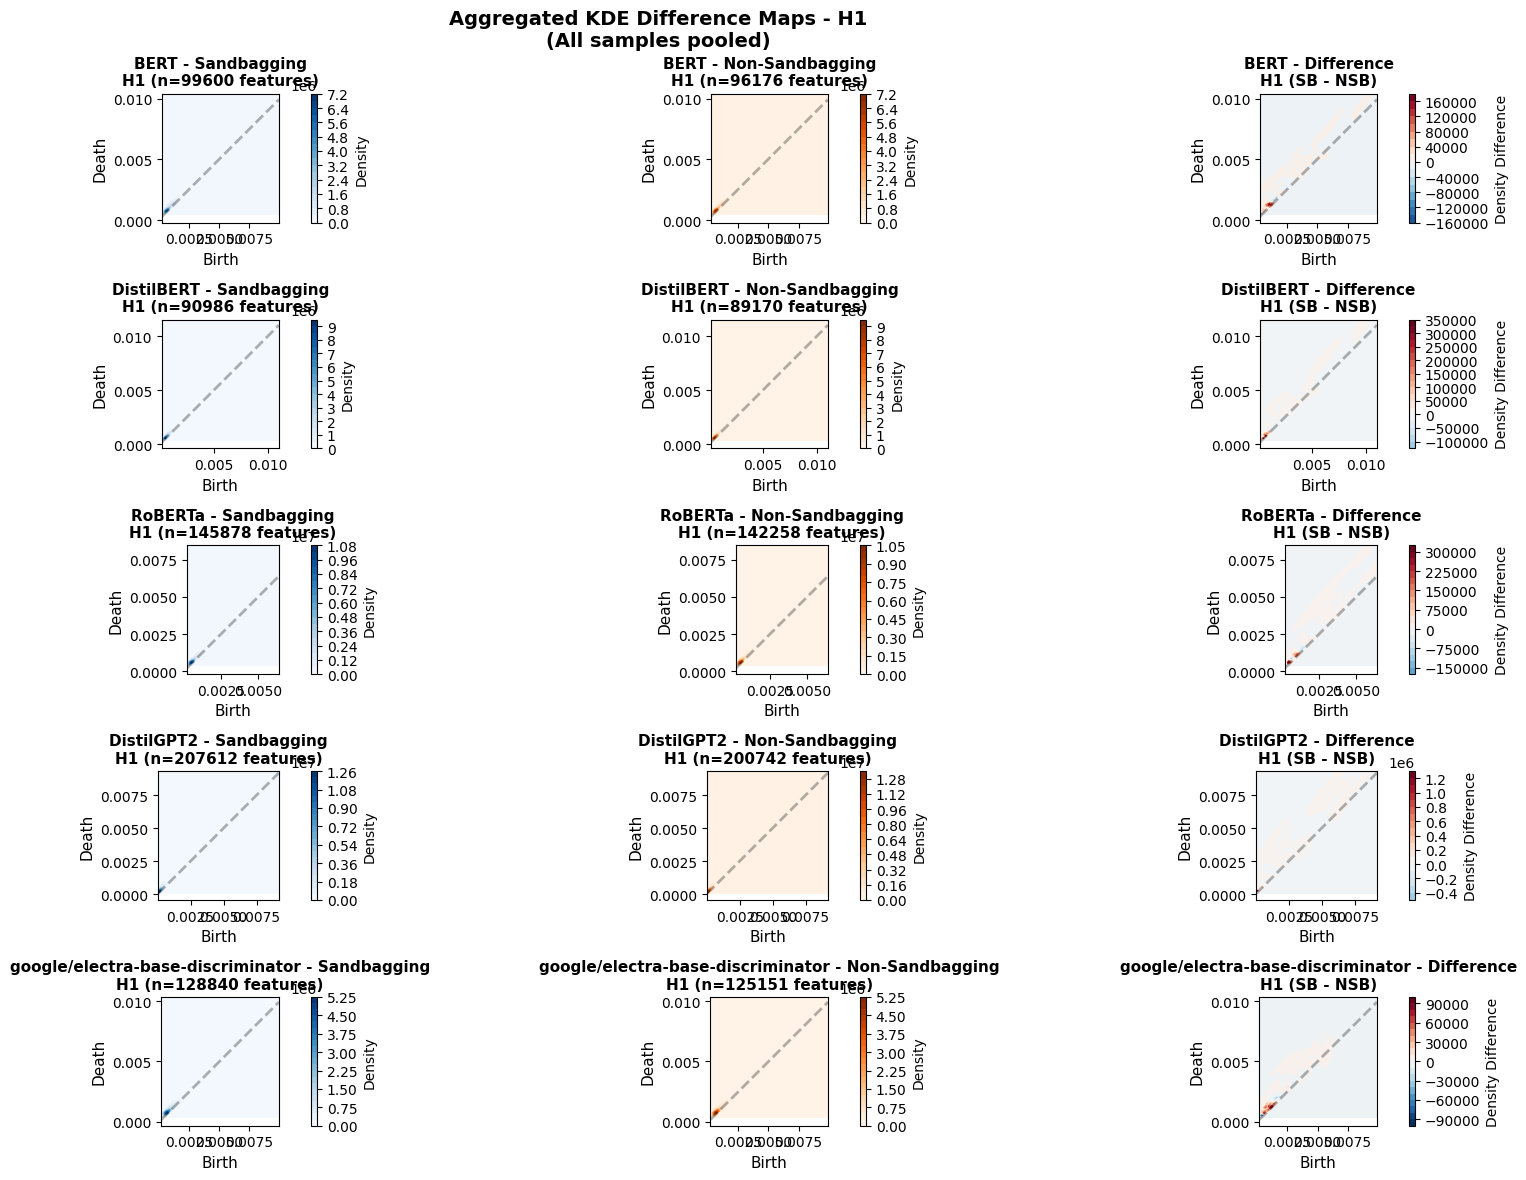


2. Persistence Images...
Computing persistence images for BERT...
Computing persistence images for DistilBERT...
Computing persistence images for RoBERTa...
Computing persistence images for DistilGPT2...
Computing persistence images for google/electra-base-discriminator...


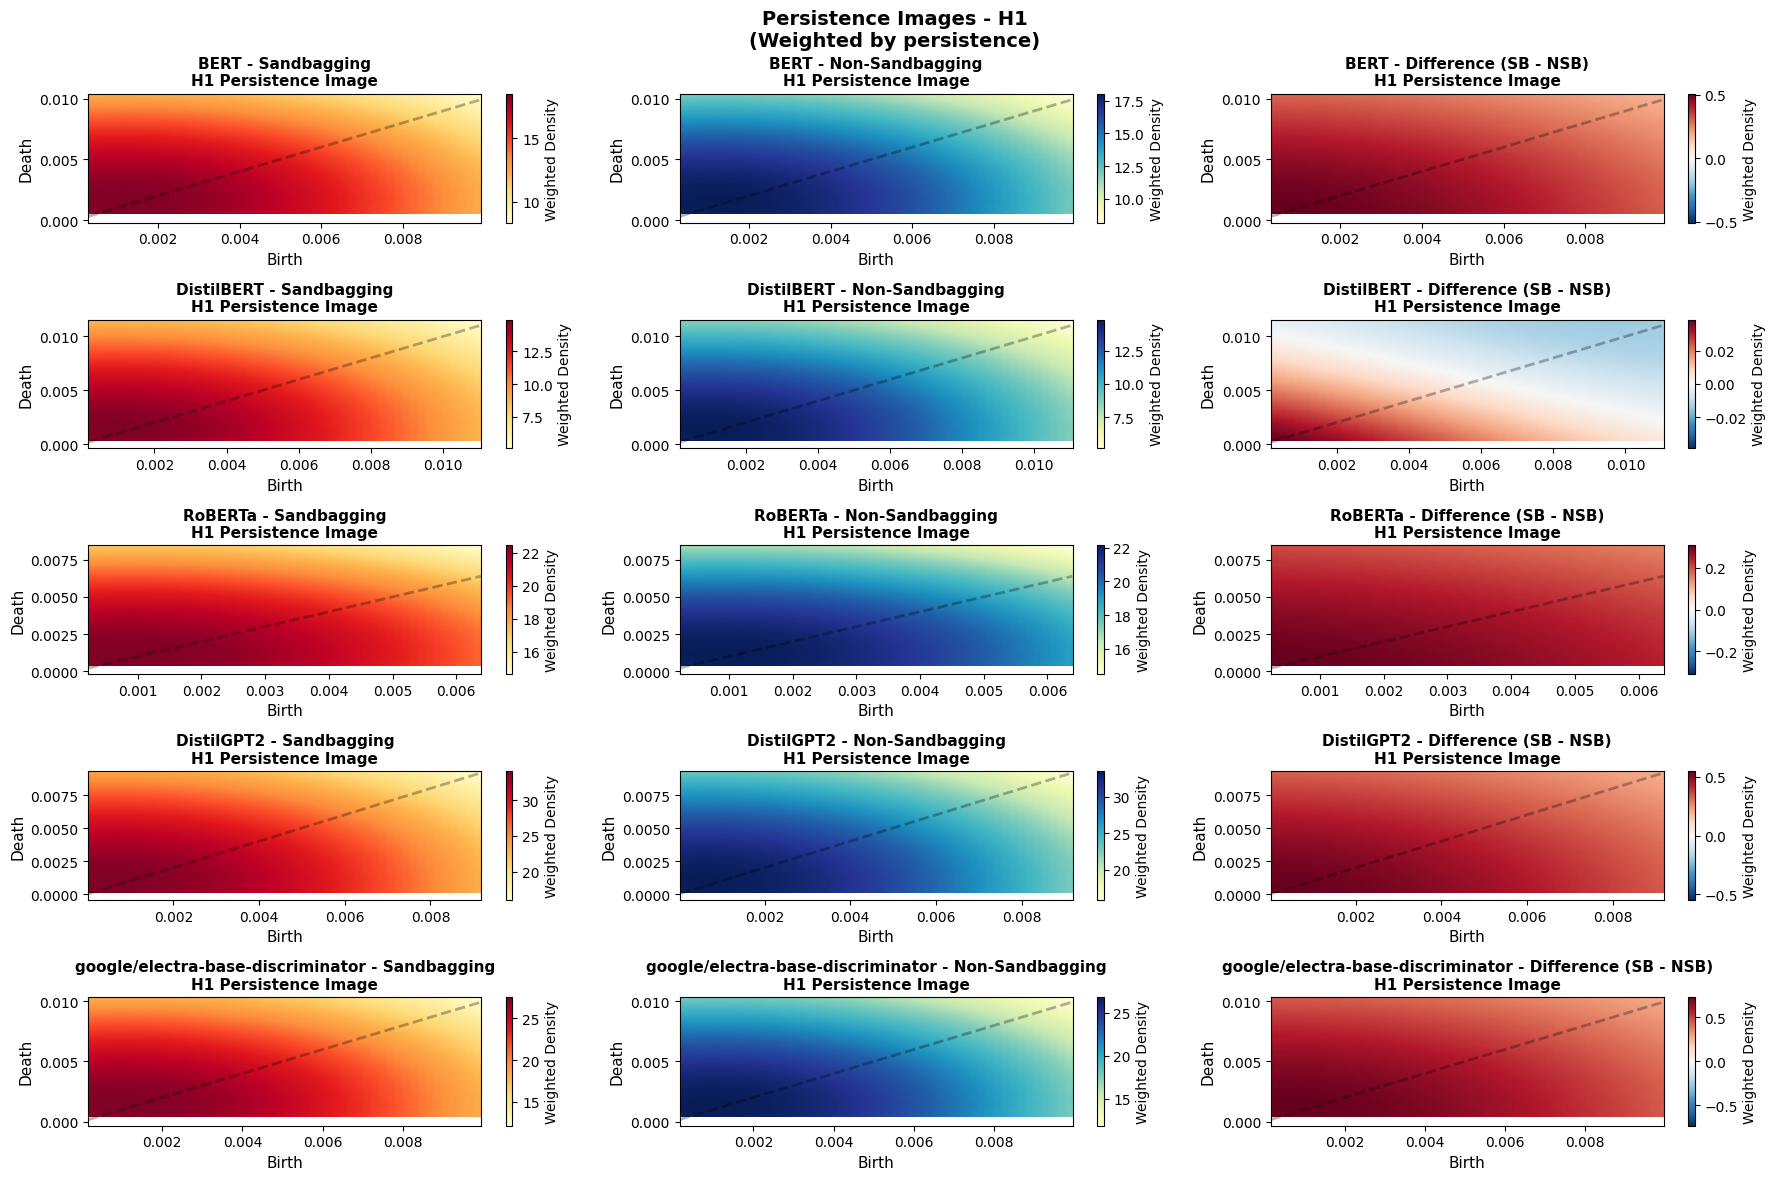


3. Betti Curves...
Computing Betti curves for BERT...
Computing Betti curves for DistilBERT...
Computing Betti curves for RoBERTa...
Computing Betti curves for DistilGPT2...
Computing Betti curves for google/electra-base-discriminator...


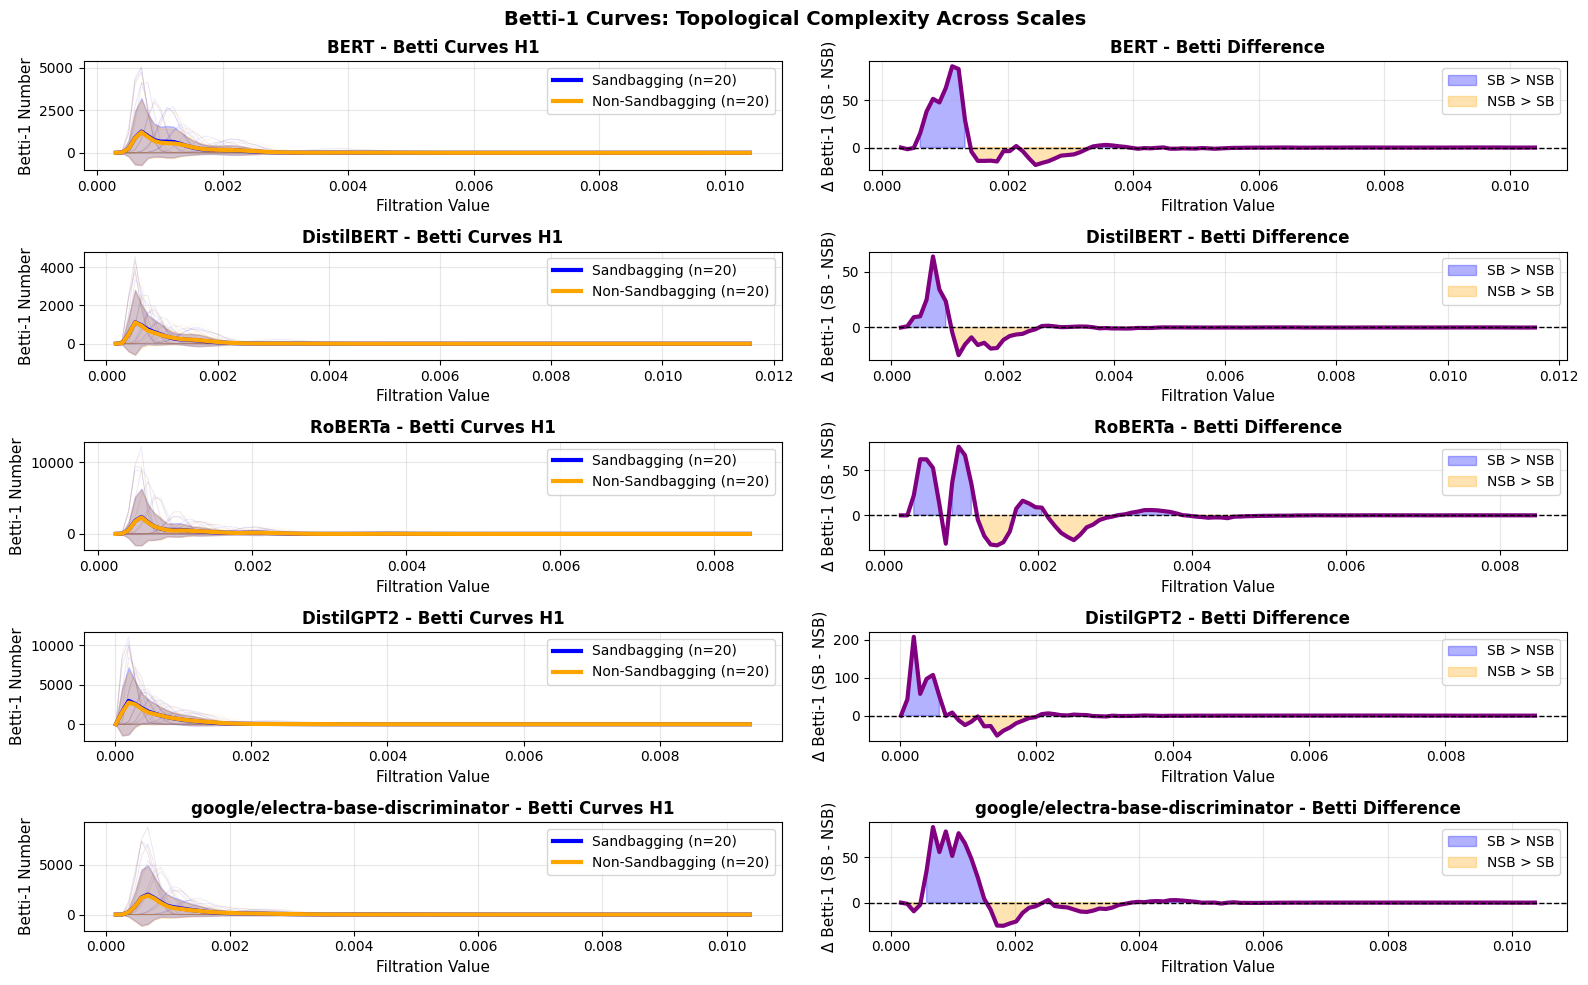


4. Persistence Landscapes...
Computing persistence landscapes for BERT...
Computing persistence landscapes for DistilBERT...
Computing persistence landscapes for RoBERTa...
Computing persistence landscapes for DistilGPT2...
Computing persistence landscapes for google/electra-base-discriminator...


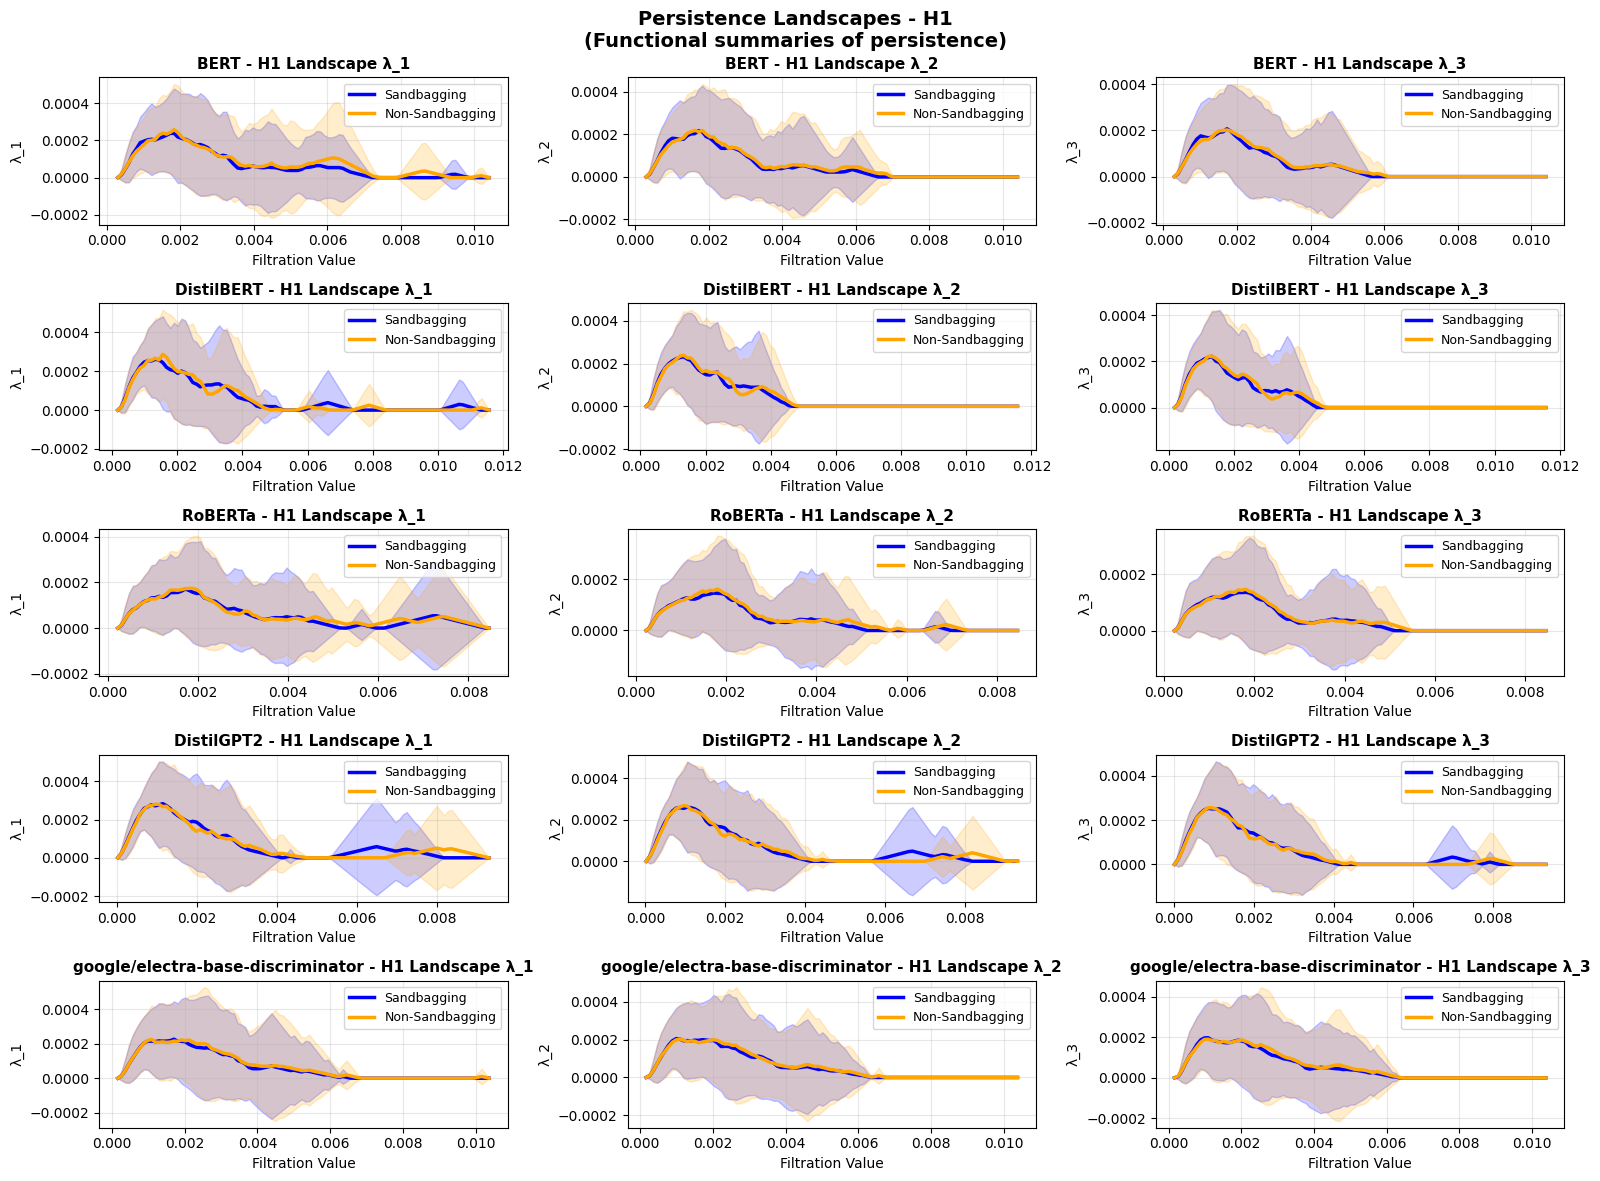


5. Cross-Model Comparison Matrix...


In [ ]:
# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

if __name__ == "__main__":
    # Define your experiments
    exp_dirs = {
        "BERT": Path("/workspace/experiments/bert-base-uncased_15prefixes_200prompts"),
        "DistilBERT": Path("/workspace/experiments/distilbert-base-uncased_15prefixes_200prompts"),
        "RoBERTa": Path("/workspace/experiments/roberta-base_15prefixes_200prompts"),
        "DistilGPT2": Path("/workspace/experiments/distilgpt2_15prefixes_200prompts"),
        "google/electra-base-discriminator": Path("/workspace/experiments/google_electra-small-discriminator_15prefixes_200prompts")
    }
    
     # OPTION 1: Use main persistence diagrams (H0, H1 only)
    print("Analyzing H1 from main persistence diagrams...")
    run_aggregated_analysis(exp_dirs, dims=[1], use_h2_experimental=False)
    
    # OPTION 2: Use H2 experimental folder (H0, H1, H2)
    # print("\n" + "="*60)
    # print("Analyzing H1 and H2 from H2 experimental data...")
    # run_aggregated_analysis(exp_dirs, dims=[1, 2], use_h2_experimental=True)
    
    # OPTION 3: Load data once and run custom visualizations
    # print("\n" + "="*60)
    # print("Custom analysis...")
    # all_data = load_multi_experiment_data(exp_dirs, use_h2_experimental=False)
    
    # Run individual visualizations
    # plot_aggregated_kde_difference(all_data, dim=1)
    # plot_persistence_images(all_data, dim=1)
    # plot_betti_curves(all_data, dim=1)
    # plot_persistence_landscapes(all_data, dim=1)



In [ ]:
if __name__ == "__main__":
    # Define your experiments
    exp_dirs = {
        "BERT": Path("/workspace/experiments/bert-base-uncased_15prefixes_200prompts"),
        "DistilBERT": Path("/workspace/experiments/distilbert-base-uncased_15prefixes_200prompts"),
        "RoBERTa": Path("/workspace/experiments/roberta-base_15prefixes_200prompts"),
        "DistilGPT2": Path("/workspace/experiments/distilgpt2_15prefixes_200prompts"),
        "google/electra-base-discriminator": Path("/workspace/experiments/google_electra-small-discriminator_15prefixes_200prompts")
    }
    
     # OPTION 1: Use main persistence diagrams (H0, H1 only)
    print("Analyzing H1 from main persistence diagrams...")
    run_aggregated_analysis_5_7(exp_dirs, dims=[1], use_h2_experimental=False)

Analyzing H1 from main persistence diagrams...
AGGREGATED TDA ANALYSIS

📦 Loading Data...
Loading BERT...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading DistilBERT...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading RoBERTa...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading DistilGPT2...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
  ✓ non_sandbagging: 20 samples (H0, H1)
    - Attention maps: 20
    - Distance matrices: 20
Loading google/electra-base-discriminator...
  ✓ sandbagging: 20 samples (H0, H1)
    - Attenti